In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
tensor_transformer = ToTensor()
full_train_data = datasets.MNIST(
    root="data", download=False, train=True, transform=tensor_transformer
)

test_data = datasets.MNIST(
    root="data", download=False, train=False, transform=tensor_transformer
)

In [3]:
print("Full training set: ", len(full_train_data), "\nTesting set: ", len(test_data))

Full training set:  60000 
Testing set:  10000


In [4]:
from torch.utils.data import random_split

In [5]:
train_size = 50000
val_size = 10000

train_data, val_data = random_split(full_train_data, [train_size, val_size])

In [6]:
print(
    "Train set: ",
    len(train_data),
    "\nVal set: ",
    len(val_data),
    "\nTest set: ",
    len(test_data),
)


Train set:  50000 
Val set:  10000 
Test set:  10000


In [7]:
from torch.utils.data import DataLoader

In [8]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [9]:
import torch.nn as nn

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.layers(x)

In [11]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10
learning_rate = 0.001

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            v_loss += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()

    # Logowanie (English logs)
    history["train_loss"].append(t_loss / len(train_loader))
    history["val_loss"].append(v_loss / len(val_loader))
    history["val_acc"].append(correct / len(val_data))
    print(
        f"Epoch {epoch + 1}/{epochs} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}"
    )

# 2. Ewaluacja i zbieranie danych do metryk
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        all_preds.extend(model(x).argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

Epoch 1/10 | Loss: 0.2470 | Val Acc: 0.9672
Epoch 2/10 | Loss: 0.0680 | Val Acc: 0.9800
Epoch 3/10 | Loss: 0.0476 | Val Acc: 0.9831
Epoch 4/10 | Loss: 0.0369 | Val Acc: 0.9842
Epoch 5/10 | Loss: 0.0288 | Val Acc: 0.9866
Epoch 6/10 | Loss: 0.0219 | Val Acc: 0.9893
Epoch 7/10 | Loss: 0.0182 | Val Acc: 0.9882
Epoch 8/10 | Loss: 0.0162 | Val Acc: 0.9893
Epoch 9/10 | Loss: 0.0125 | Val Acc: 0.9901
Epoch 10/10 | Loss: 0.0104 | Val Acc: 0.9892


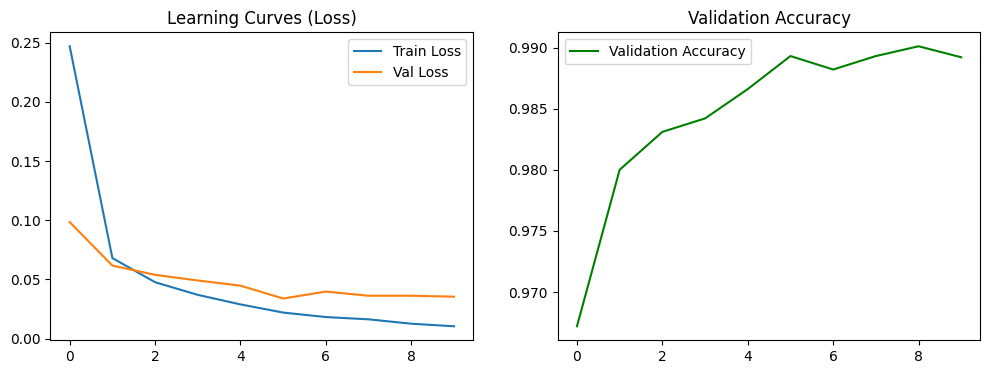

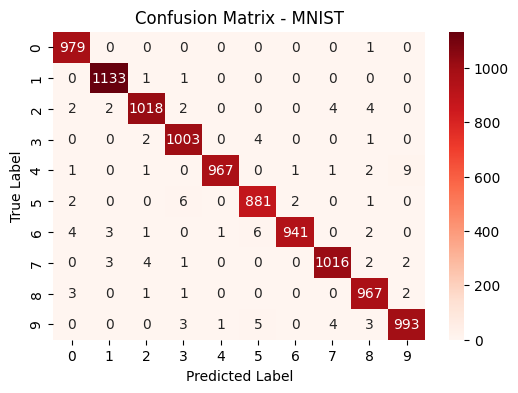


--- Full Classification Report ---
              precision    recall  f1-score   support

           0     0.9879    0.9990    0.9934       980
           1     0.9930    0.9982    0.9956      1135
           2     0.9903    0.9864    0.9883      1032
           3     0.9862    0.9931    0.9896      1010
           4     0.9979    0.9847    0.9913       982
           5     0.9833    0.9877    0.9855       892
           6     0.9968    0.9823    0.9895       958
           7     0.9912    0.9883    0.9898      1028
           8     0.9837    0.9928    0.9882       974
           9     0.9871    0.9841    0.9856      1009

    accuracy                         0.9898     10000
   macro avg     0.9897    0.9897    0.9897     10000
weighted avg     0.9898    0.9898    0.9898     10000



In [13]:
# 3. Wykresy (Learning Curves)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Learning Curves (Loss)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Validation Accuracy", color="green")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# 4. Confusion Matrix (Macierz pomyłek)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST")
plt.show()

# 5. Wszystkie metryki (Precision, Recall, F1-Score)
print("\n--- Full Classification Report ---")
print(classification_report(all_labels, all_preds, digits=4))

In [14]:
model.eval()
correct_img, correct_label = None, None
wrong_img, wrong_label, wrong_pred = None, None, None

# Przeszukujemy loader, aż znajdziemy oba przypadki
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Szukamy poprawnego (jeśli jeszcze nie mamy)
        if correct_img is None:
            c_idx = (preds == labels).nonzero(as_tuple=True)[0]
            if len(c_idx) > 0:
                correct_img = images[c_idx[0]].unsqueeze(0)
                correct_label = labels[c_idx[0]].item()

        # Szukamy błędu (jeśli jeszcze nie mamy)
        if wrong_img is None:
            w_idx = (preds != labels).nonzero(as_tuple=True)[0]
            if len(w_idx) > 0:
                wrong_img = images[w_idx[0]].unsqueeze(0)
                wrong_label = labels[w_idx[0]].item()
                wrong_pred = preds[w_idx[0]].item()

        # Jeśli znaleźliśmy oba, przerywamy pętlę
        if correct_img is not None and wrong_img is not None:
            break

print(f"Case 1 (Correct): True {correct_label}, Pred {correct_label}")
print(f"Case 2 (Wrong): True {wrong_label}, Pred {wrong_pred}")

Case 1 (Correct): True 7, Pred 7
Case 2 (Wrong): True 4, Pred 9


In [15]:
from captum.attr import IntegratedGradients, NoiseTunnel
from captum.attr import visualization as viz
import numpy as np

/home/mikolajmalolepszy/Desktop/Projects/mgr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

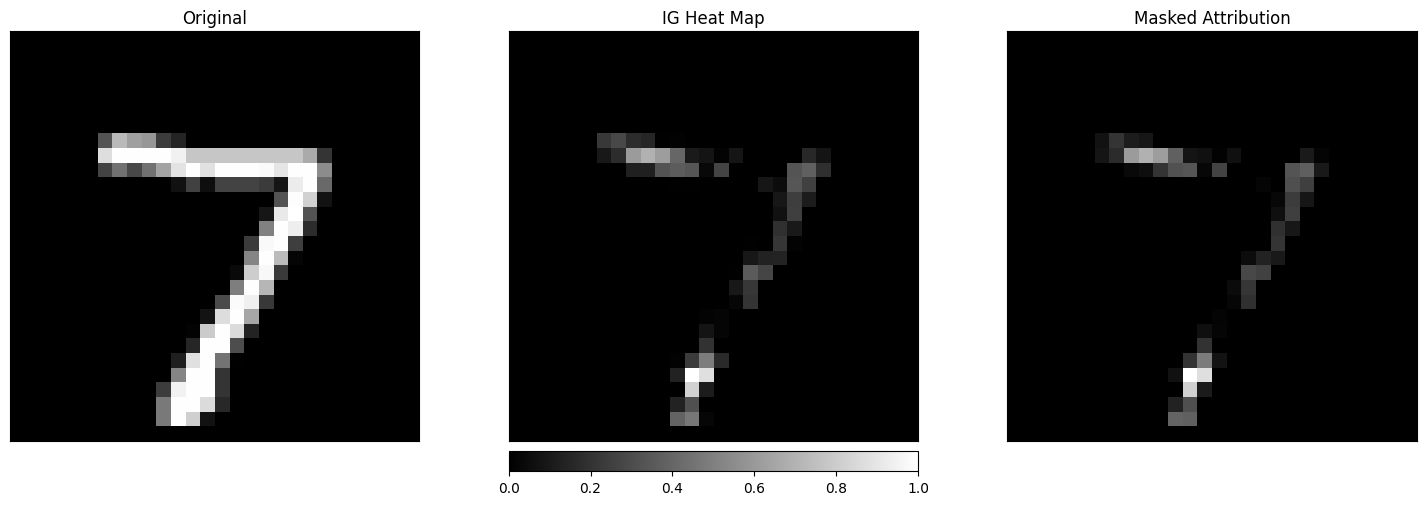

In [16]:
# 1. Przygotowanie modelu i danych
model.eval()
input_img = correct_img.to(device)
input_img.requires_grad = True

# 2. Inicjalizacja i obliczenie IG
ig = IntegratedGradients(model)
attr_ig = ig.attribute(input_img, target=correct_label, n_steps=50)

# 3. Przygotowanie danych do wizualizacji
# Wyciągamy obrazek jako (H, W)
img_np = input_img.squeeze().cpu().detach().numpy()
attr_np = attr_ig.squeeze().cpu().detach().numpy()

# Klucz do skali szarości: musimy mieć format (H, W, 1)
img_vis = np.expand_dims(img_np, axis=2)
attr_vis = np.expand_dims(attr_np, axis=2)

# 4. Wizualizacja
# Używamy plt.set_cmap przed wywołaniem, aby spróbować wymusić styl
plt.set_cmap("gray")

fig, _ = viz.visualize_image_attr_multiple(
    attr_vis,
    img_vis,
    ["original_image", "heat_map", "masked_image"],
    ["all", "positive", "positive"],
    show_colorbar=True,
    titles=["Original", "IG Heat Map", "Masked Attribution"],
    fig_size=(15, 5),
    cmap="gray",  # To ustawi środkowy panel na szaro
)


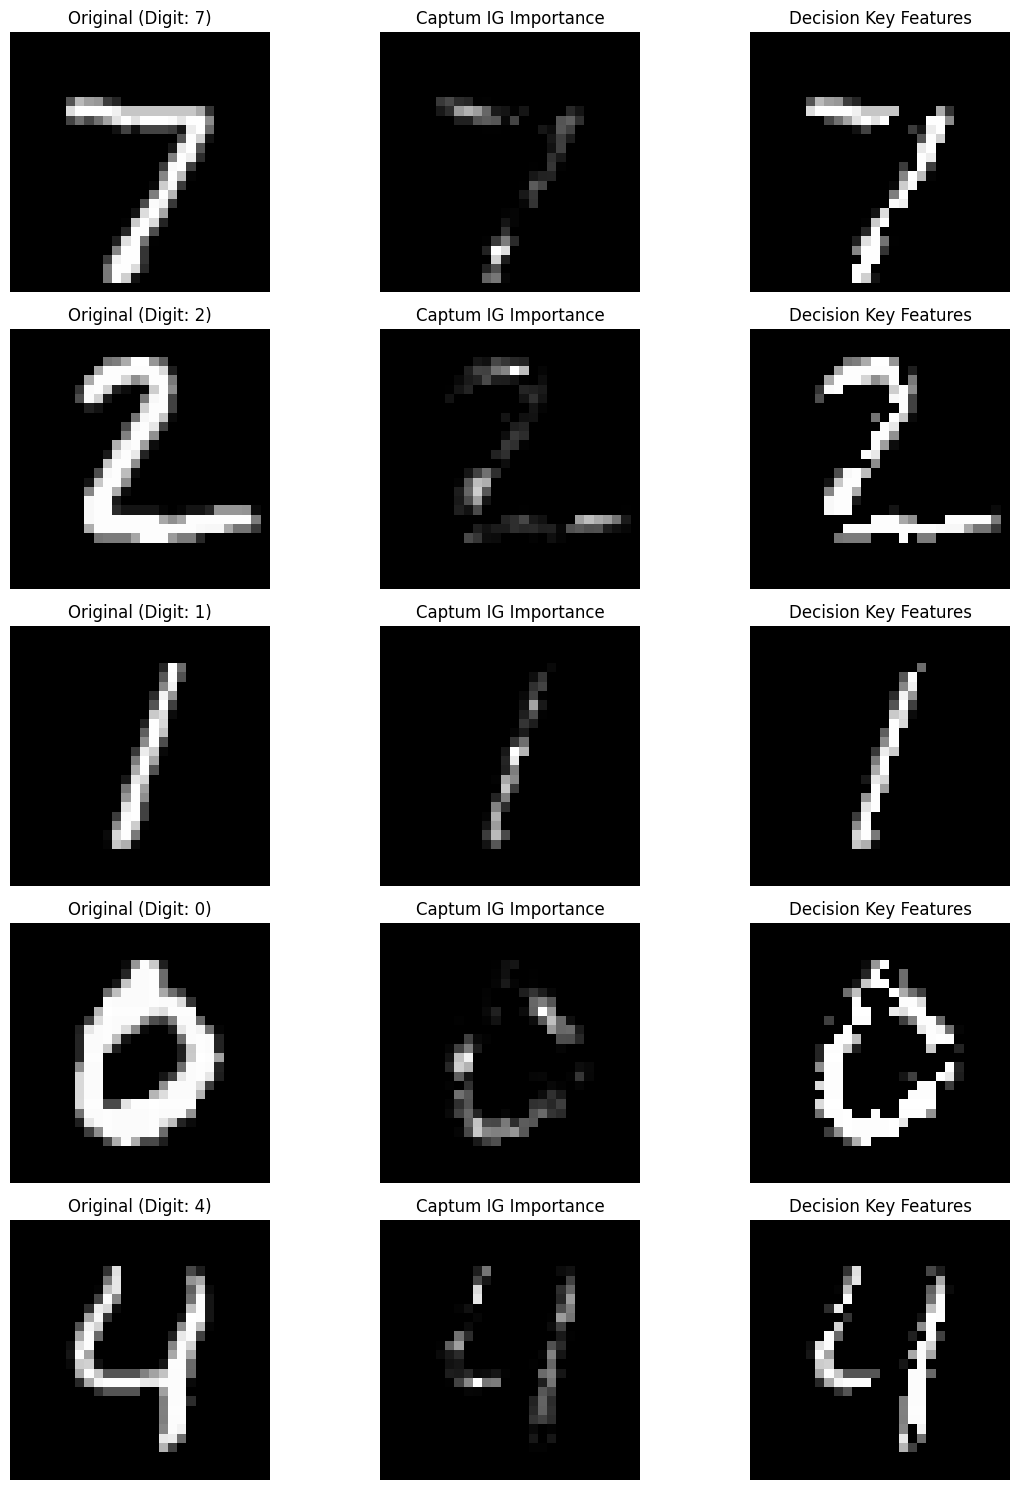

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import IntegratedGradients


def benchmark_captum(model, test_loader, device, num_cases=5):
    model.eval()
    ig = IntegratedGradients(model)

    # Pobieramy paczkę danych
    images, labels = next(iter(test_loader))
    images, labels = images[:num_cases], labels[:num_cases]

    fig, axes = plt.subplots(num_cases, 3, figsize=(12, 3 * num_cases))

    for i in range(num_cases):
        img = images[i].unsqueeze(0).to(device)
        img.requires_grad = True
        target = labels[i].item()

        # Obliczamy IG
        attr = ig.attribute(img, target=target, n_steps=50)

        # Konwersja do numpy dla matplotlib
        img_np = img.squeeze().cpu().detach().numpy()
        attr_np = attr.squeeze().cpu().detach().numpy()

        # 1. Oryginał
        axes[i, 0].imshow(img_np, cmap="gray")
        axes[i, 0].set_title(f"Original (Digit: {target})")
        axes[i, 0].axis("off")

        # 2. Atrybucja (Heat Map) - vmin=0 żeby skupić się na pozytywnym wpływie
        axes[i, 1].imshow(attr_np, cmap="gray", vmin=0)
        axes[i, 1].set_title("Captum IG Importance")
        axes[i, 1].axis("off")

        # 3. Nałożenie (Co faktycznie wpłynęło na wynik)
        mask = np.where(attr_np > 0, img_np, 0)
        axes[i, 2].imshow(mask, cmap="gray")
        axes[i, 2].set_title("Decision Key Features")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


# Wywołanie
benchmark_captum(model, test_loader, device, num_cases=5)

In [22]:
from pathlib import Path

noised_path = Path("data/MNIST/noised")
for i in range(10):
    (noised_path / str(i)).mkdir(parents=True, exist_ok=True)

In [23]:
import torch


def add_gaussian_noise(tensor, sigma=0.1):
    # Generujemy szum o tym samym kształcie co obrazek
    noise = torch.randn_like(tensor) * sigma
    noisy_tensor = tensor + noise
    # Przycinamy wartości do zakresu [0, 1]
    return torch.clamp(noisy_tensor, 0.0, 1.0)

In [42]:
from torchvision.utils import save_image

sigma_value = 0.001
img_counter = 0

# Przygotowanie folderów
for i in range(10):
    (noised_path / str(i)).mkdir(parents=True, exist_ok=True)

print(f"Generowanie zaszumionego zbioru w: {noised_path}")

# 2. Tylko przetwarzanie danych (bez modelu)
for images, labels in test_loader:
    # Dodajemy szum
    noisy_batch = add_gaussian_noise(images, sigma=sigma_value)

    for i in range(len(images)):
        label = labels[i].item()

        file_path = noised_path / str(label) / f"img_{img_counter}.png"

        # Zapisujemy
        save_image(noisy_batch[i], file_path)
        img_counter += 1

Generowanie zaszumionego zbioru w: data/MNIST/noised
